# 03 — Volt-VAr curtailment detection and attribution

This notebook asks a narrower question than Volt-VAr conformance: **is there empirical evidence that absorbing reactive power constrained active-power output, and how much counterfactual-supported generation may be attributed to that constraint?**

## Evidence model

- **Method A** detects an apparent-power-limit symptom and reports a reactive-headroom displacement proxy. It is not lost energy.
- **Method B** adds the GHI counterfactual and reports nested evidence tiers.
- Tier 1: high-voltage absorbing Q.
- Tier 2: absorbing Q plus operation near the selected empirical apparent-power limit.
- Tier 3: counterfactual P above the active-power headroom implied by measured Q.
- Tier 4: Tier 2 and Tier 3 together, with attributed energy limited to the part of observed loss lying above the Q-constrained headroom.

A separate required-Q scenario estimates the constraint that would arise from the standards-required Q curve. It is a scenario, not evidence of measured inverter behaviour.

In [1]:
%matplotlib inline
import importlib
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
REPO_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'bms_sa_review').is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError(f'Cannot find repository root from {HERE}')
PACKAGE_ROOT = REPO_ROOT / 'bms_sa_review'
SHARED = PACKAGE_ROOT / 'shared'
LIB = PACKAGE_ROOT / 'data_query' / 'lib'
for path in (REPO_ROOT, PACKAGE_ROOT, SHARED, LIB):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from bms_sa_review.shared.aws_config import aq
import analysis_contract as contract
import conformance_queries as cq
import conformance_metrics as cm
import voltvar_params as vp
import voltvar_queries as vq
import voltvar_metrics as vm
import voltvar_plots as vpl
for module in (contract, cq, cm, vp, vq, vm, vpl):
    importlib.reload(module)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 190)

In [2]:
CONFIG = contract.AnalysisConfig(
    years=(2024, 2025), flex_selection='exclude',
    rating_basis='ac_capacity_kw', empirical_limit_basis='s_99',
    voltage_aggregation='avg', capability_profile='review_corrected',
).validate()
PARAMS = vp.VoltVarParams(
    years=CONFIG.years,
    v_low=240.0, v_high=253.0,
    peak_hour_start=11, peak_hour_end=14,
    ghi_cs_ratio_min=0.95, apply_ghi_filter=True,
    empirical_limit_basis='s_99',
    tolerance_basis='ac_capacity_kw',
    rating_basis='ac_capacity_kw',
    require_apparent_limit_symptom=True,
    flex_selection='exclude',
).validate()
display(contract.manifest(CONFIG))
display(vp.describe(PARAMS))

,setting,value
0,database,solar_analytics_iceberg
1,years,"2024, 2025"
2,interval_minutes,5.0
3,site_nonconf_threshold,0.1
4,minimum_site_intervals,1
5,flex_selection,exclude
6,rating_basis,ac_capacity_kw
7,empirical_limit_basis,s_99
8,voltage_aggregation,avg
9,capability_profile,review_corrected


,parameter,value
0,years,"(2024, 2025)"
1,v_low,240.0
2,v_high,253.0
3,peak_hour_start,11
4,peak_hour_end,14
5,ghi_cs_ratio_min,0.95
6,apply_ghi_filter,True
7,empirical_limit_basis,s_99
8,tolerance_basis,ac_capacity_kw
9,tolerance_fraction,0.04


## 1. Input coverage and Stage 2 baseline

In [3]:
coverage = vq.fetch_input_coverage(aq, CONFIG, PARAMS)
stage2_baseline = vq.fetch_stage2_vvar_baseline(aq, CONFIG, PARAMS)
meta = cq.fetch_metadata(aq, CONFIG)
display(coverage)
display(stage2_baseline)
display(cm.validate_metadata(meta))

,dataset,year,n_rows,n_sites
0,all_uncurtailedpv,2024,264337213,13844
1,all_uncurtailedpv,2025,222885527,12617
2,structured_data,2024,454425592,13967
3,structured_data,2025,387065417,12737


,year,assessable_sites,capability_assessable_intervals,reduced_nonconf_intervals,apparent_limit_symptom_intervals,counterfactual_curtailment_intervals,curtailed_kwh
0,2024,14123,332234972,159996118,138588,6514,111.092172
1,2025,12913,291881647,134158435,90211,3761,48.022243


,field,sites_with_multiple_values
0,n_state_values,0
1,n_dnsp_values,0
2,n_oem_values,0
3,n_ac_capacity_values,0
4,n_s99_values,0


## 2. Method A — empirical apparent-limit symptom

The symptom requires average site voltage in 240–253 V, absorbing Q, the selected solar/GHI window, and apparent power within the selected tolerance of the empirical limit. `S_99` is an observed limit proxy, not verified manufacturer S_rated.

In [4]:
method_a_site_year = vq.fetch_method_a_site_year(aq, CONFIG, PARAMS)
method_a_enriched, method_a_summary = vm.method_a_summary(
    method_a_site_year, CONFIG.interval_h)
display(method_a_summary)
display(method_a_enriched.sort_values('headroom_displacement_kwh', ascending=False).head(20))
print('The headroom quantity is a symptom proxy, not a lost-energy estimate.')

,year,eligible_sites,symptom_sites,eligible_intervals,symptom_intervals,symptom_site_pct,symptom_interval_pct,headroom_displacement_proxy_kwh
0,2024,13080,6337,33605200,2909431,48.448012,8.657681,43606.020285
1,2025,11863,5774,28861208,2615864,48.672343,9.063598,38629.552410


,site_id,year,eligible_count,absorbing_q_count,symptom_count,headroom_displacement_kw_sum,avg_symptom_voltage,avg_symptom_p_kw,avg_symptom_q_kvar,headroom_displacement_kwh,affected
15314,1493831319,2024,5353,5327,3377,3615.833366,249.922638,8.653992,-4.453005,301.319447,True
22141,2105830595,2025,4771,4771,3813,3460.461062,247.290782,8.876166,-4.111075,288.371755,True
18904,1660691446,2025,2949,2949,1240,3255.212153,251.838895,11.942972,-8.434457,271.267679,True
16015,2105830595,2024,4524,4524,3738,3053.458942,246.845171,9.001445,-3.904943,254.454912,True
3225,1819352492,2024,5185,5185,3218,3040.360466,247.746846,28.591767,-7.372008,253.363372,True
23099,508858566,2025,4182,4181,3147,2984.428012,250.885669,8.887910,-4.214090,248.702334,True
24402,1197777914,2025,4479,4474,1892,2726.761575,251.183848,8.209939,-5.101875,227.230131,True
18733,1598634062,2024,4611,4611,1873,2628.288356,241.923545,8.369325,-5.053194,219.024030,True
24730,675933004,2025,2807,2805,1380,2626.251011,246.273068,27.592205,-10.336926,218.854251,True
18869,1686920472,2025,2798,2742,2094,2574.903290,249.679045,8.653189,-4.762852,214.575274,True


The headroom quantity is a symptom proxy, not a lost-energy estimate.


## 3. Method B — counterfactual-supported attribution

Missing counterfactuals remain missing. Energy percentages use only counterfactual-covered potential generation. The measured-Q result requires an apparent-limit symptom by default; the required-Q result is displayed separately as a standards scenario.

,year,eligible_sites,counterfactual_covered_sites,tier1_absorbing_intervals,tier2_apparent_limit_intervals,tier3_counterfactual_above_headroom_intervals,tier4_attributed_intervals,tier4_affected_sites,attributed_measured_q_kwh,required_q_scenario_kwh,counterfactual_covered_potential_kwh,attributed_pct_of_covered_potential
0,2024,13080,12949,15280539,2909431,474323,373682,3124,3655.491763,15851.429268,1.098402e+07,0.033280
1,2025,11863,11724,13455736,2615864,374549,299271,2866,2714.091200,12259.603372,9.612079e+06,0.028236


,evidence_tier,n_intervals,n_sites
0,Tier 1: absorbing Q,28736275,9793
1,Tier 2: apparent-limit symptom,5525295,7253
2,Tier 3: counterfactual above measured-Q headroom,848872,4618
3,Tier 4: symptom + attributable displacement,672953,3790


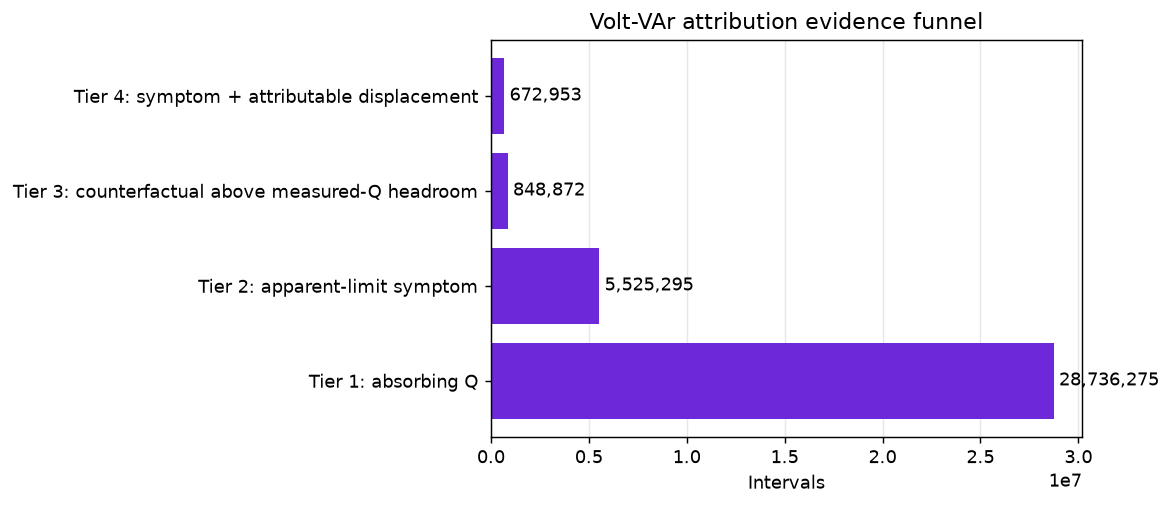

In [5]:
method_b_site_year = vq.fetch_method_b_site_year(aq, CONFIG, PARAMS)
method_b_enriched, method_b_summary = vm.method_b_summary(
    method_b_site_year, CONFIG.interval_h)
tiers = vm.evidence_tier_table(method_b_site_year)
display(method_b_summary)
display(tiers)
vpl.plot_evidence_tiers(tiers);

## 4. Fleet breakdowns and concentration


Volt-VAr attribution by state


,state,n_sites,affected_sites,attributed_kwh,covered_potential_kwh,affected_site_pct,attributed_pct_of_covered_potential
3,QLD,5551,1655,2490.350893,8.857366e+06,29.814448,0.028116
1,NSW,5568,1389,2120.037194,7.955033e+06,24.946121,0.026650
6,VIC,1160,285,907.187435,1.032529e+06,24.568966,0.087861
5,TAS,353,136,428.565905,2.733289e+05,38.526912,0.156795
4,SA,1190,127,160.247225,1.325150e+06,10.672269,0.012093
7,WA,466,142,145.834613,6.616283e+05,30.472103,0.022042
0,ACT,165,33,107.254463,3.603268e+05,20.0,0.029766
2,NT,104,23,10.105234,1.307349e+05,22.115385,0.007730



Volt-VAr attribution by dnsp


,dnsp,n_sites,affected_sites,attributed_kwh,covered_potential_kwh,affected_site_pct,attributed_pct_of_covered_potential
6,Ergon,3159,888,1566.118684,5.884991e+06,28.110161,0.026612
1,Ausgrid,2550,667,1115.399144,4.101496e+06,26.156863,0.027195
5,Energex,2296,725,834.156272,2.816824e+06,31.576655,0.029613
7,Essential,1379,413,675.934197,1.800829e+06,29.949239,0.037535
4,Endeavour,1743,357,441.745335,2.215743e+06,20.481928,0.019937
13,TasNetworks,342,132,405.982666,2.606461e+05,38.596491,0.155760
2,Ausnet,359,84,343.383781,3.174062e+05,23.398329,0.108184
11,Powercor,363,102,255.138438,3.850369e+05,28.099174,0.066263
9,Jemena,123,34,190.600867,1.503602e+05,27.642276,0.126763
12,SAPN,1170,121,148.144662,1.281119e+06,10.34188,0.011564



Volt-VAr attribution by oem


,oem,n_sites,affected_sites,attributed_kwh,covered_potential_kwh,affected_site_pct,attributed_pct_of_covered_potential
12,Generic Inverter,4151,1370,2180.045077,5.048988e+06,33.004095,0.043178
35,Sungrow,2606,978,1429.625728,4.307558e+06,37.52878,0.033189
9,Fronius,2748,512,1083.411524,3.812014e+06,18.631732,0.028421
14,GoodWe,1774,472,996.263449,3.289232e+06,26.606539,0.030289
25,SMA,1219,231,320.613425,1.771634e+06,18.949959,0.018097
31,SolarEdge,370,83,174.246944,5.394827e+05,22.432432,0.032299
33,Solis,249,31,56.556796,2.446161e+05,12.449799,0.023121
0,ABB,242,15,28.437713,3.095817e+05,6.198347,0.009186
15,Growatt,74,14,19.315648,7.294630e+04,18.918919,0.026479
5,Delta Energy,72,11,19.184339,6.243186e+04,15.277778,0.030728



Volt-VAr attribution by install_year


,install_year,n_sites,affected_sites,attributed_kwh,covered_potential_kwh,affected_site_pct,attributed_pct_of_covered_potential
17,2024,1953,816,1698.410433,2.786359e+06,41.781874,0.060954
15,2022,1891,532,1187.440200,3.334161e+06,28.133263,0.035614
14,2021,2459,657,1151.478230,4.463879e+06,26.718178,0.025795
16,2023,1621,664,1102.014431,2.808994e+06,40.962369,0.039232
13,2020,2707,578,809.516847,3.866584e+06,21.35205,0.020936
18,2025,956,223,215.323263,6.112362e+05,23.32636,0.035228
12,2019,1668,239,139.127343,1.577388e+06,14.328537,0.008820
11,2018,619,43,16.921458,5.996760e+05,6.946688,0.002822
9,2016,184,8,9.979650,1.140745e+05,4.347826,0.008748
5,2012,26,1,6.690374,1.738857e+04,3.846154,0.038476


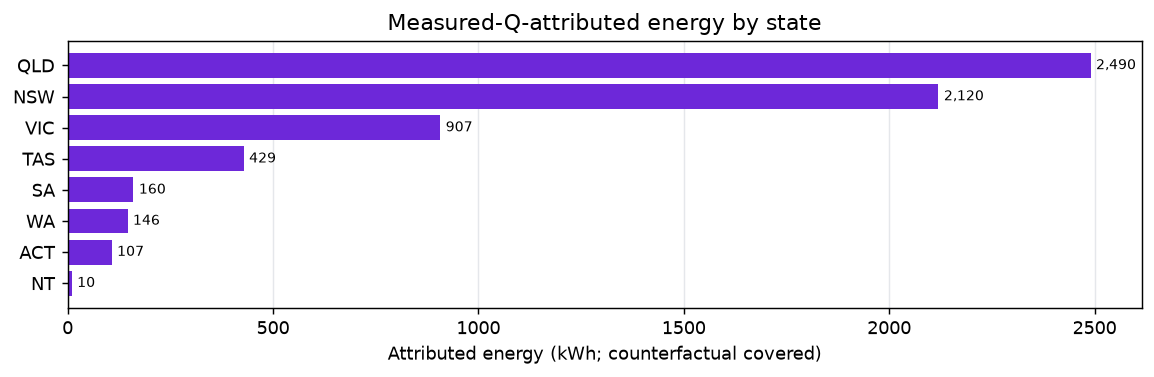

In [6]:
vvar_breakdowns = {}
for group in ('state', 'dnsp', 'oem', 'install_year'):
    vvar_breakdowns[group] = vm.group_breakdown(
        method_b_enriched, meta, group, min_sites=20)
    print(f'\nVolt-VAr attribution by {group}')
    display(vvar_breakdowns[group])

vpl.plot_group_energy(vvar_breakdowns['state'], 'state',
                      'Measured-Q-attributed energy by state');

,top_site_share_pct,cumulative_energy_share_pct
0,1,13.157739
1,5,38.026048
2,10,55.841303
3,20,76.221146
4,50,96.713290


,site_id,attributed_measured_q_kwh,site_share_pct,cumulative_energy_share_pct
0,1805446999,54.075823,0.026385,0.848970
1,276149647,31.534031,0.052770,1.344042
2,2105830595,31.282103,0.079156,1.835159
3,476487840,30.942503,0.105541,2.320944
4,1484486619,28.737354,0.131926,2.772110
5,1056369556,27.398267,0.158311,3.202252
6,1598634062,27.318075,0.184697,3.631135
7,175225288,27.217590,0.211082,4.058441
8,854764866,26.882511,0.237467,4.480486
9,1859863480,25.337019,0.263852,4.878267


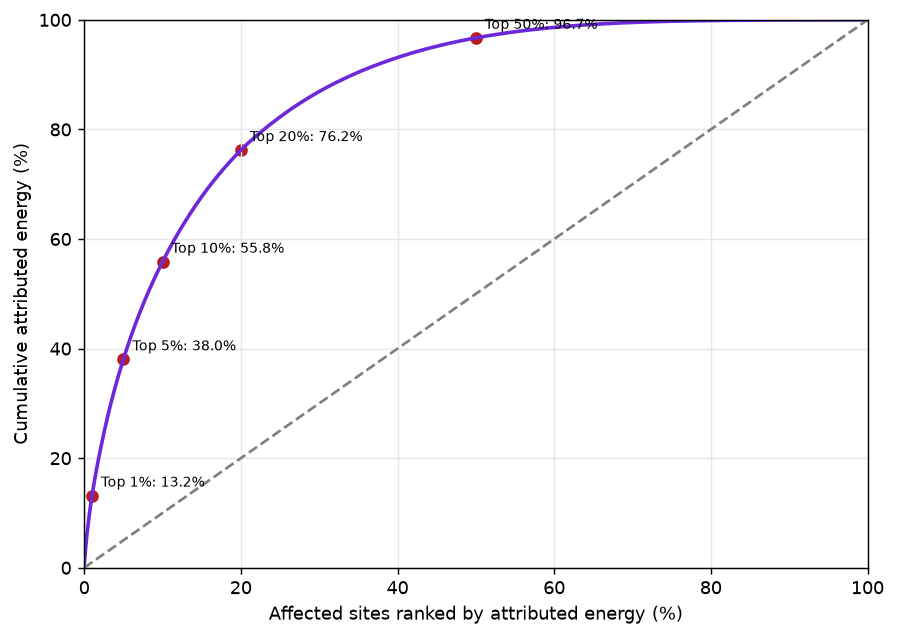

In [7]:
ranked, concentration = vm.concentration(method_b_enriched)
display(pd.DataFrame({'top_site_share_pct': concentration.keys(),
                      'cumulative_energy_share_pct': concentration.values()}))
if not ranked.empty:
    display(ranked.head(20))
    vpl.plot_concentration(ranked, concentration);

## 5. Selected-site validation

The example is chosen from Tier 4 only. The plotted voltage is the average site voltage already stored in `structured_data_v2`, so it matches the selected production aggregation instead of selecting one circuit or substituting maximum circuit voltage.

,site_id,t_stamp,actual_day,year,V,P_kW,Q_kvar,GHI,GHI_cs,rating_capacity,empirical_limit,tolerance_capacity,uncurtailed_P,S_apparent,required_q_kvar,pmax_measured_q_kw,pmax_required_q_kw,apparent_limit_symptom
0,1805446999,2024-01-01 01:00:00,2024-01-01,2024,246.85,9.491210,-2.713793,1006.66,958.21,10.0,9.922542,10.0,9.946362,9.871562,-2.283333,9.544222,9.656253,True
1,1805446999,2024-01-01 01:05:00,2024-01-01,2024,247.55,9.477767,-2.753216,1006.66,971.67,10.0,9.922542,10.0,9.891682,9.869562,-2.516667,9.532924,9.598085,True
2,1805446999,2024-01-01 01:10:00,2024-01-01,2024,249.05,9.246820,-3.470440,1018.36,971.67,10.0,9.922542,10.0,9.983723,9.876620,-3.016667,9.295853,9.452860,True
3,1805446999,2024-01-01 01:15:00,2024-01-01,2024,249.30,9.273783,-3.424340,1018.36,983.47,10.0,9.922542,10.0,9.905821,9.885806,-3.100000,9.312934,9.425860,True
4,1805446999,2024-01-01 01:20:00,2024-01-01,2024,248.95,9.307797,-3.336383,1028.42,983.47,10.0,9.922542,10.0,9.989491,9.887696,-2.983333,9.344805,9.463433,True


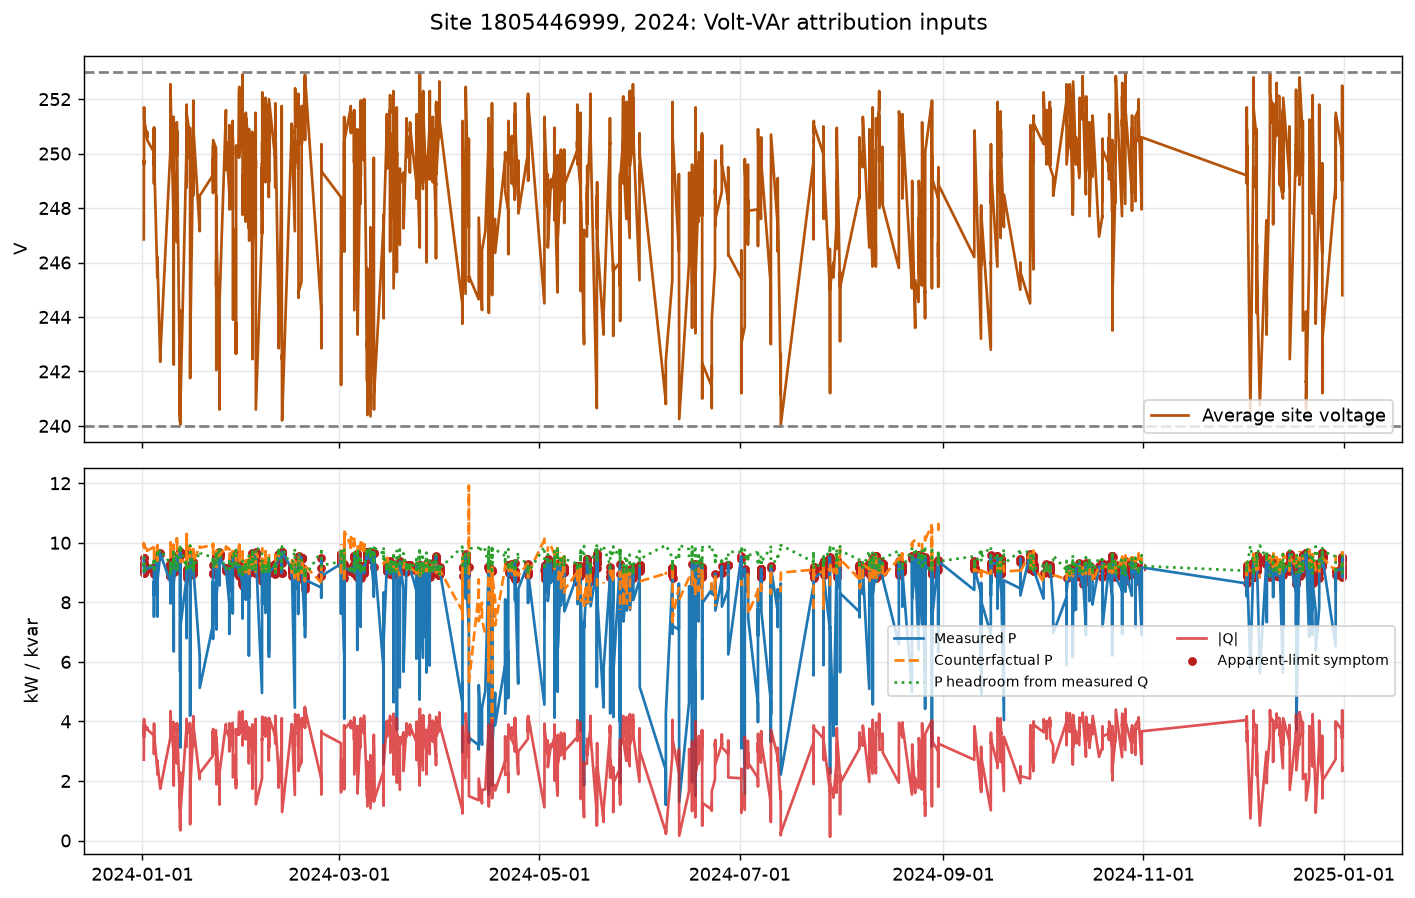

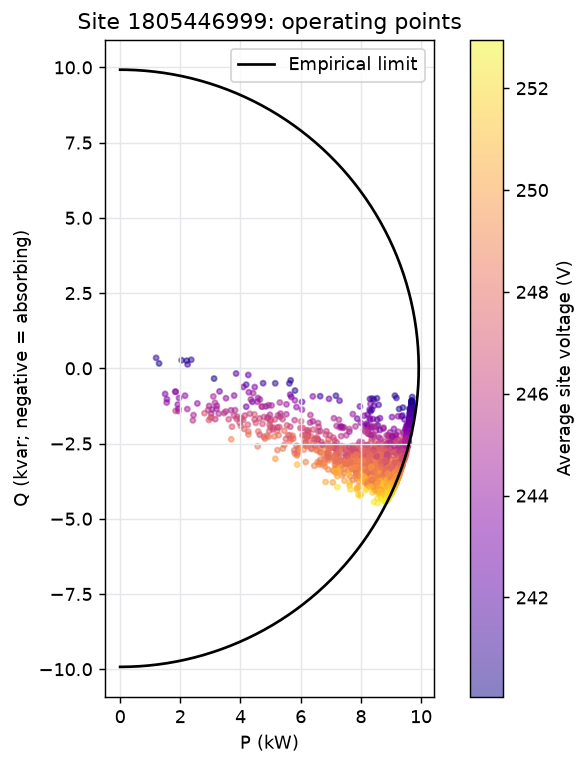

In [8]:
candidates = method_b_enriched[method_b_enriched['tier4_attributed_count'] > 0]
if candidates.empty:
    print('No Tier 4 site-year is available for plotting.')
else:
    chosen = candidates.sort_values('attributed_measured_q_kwh', ascending=False).iloc[0]
    EXAMPLE_SITE = int(chosen.site_id)
    EXAMPLE_YEAR = int(chosen.year)
    example_intervals = vq.fetch_method_b_intervals(
        aq, CONFIG, PARAMS, EXAMPLE_SITE, EXAMPLE_YEAR)
    display(example_intervals.head())
    vpl.plot_site_intervals(example_intervals, EXAMPLE_SITE, EXAMPLE_YEAR)
    vpl.plot_pq_circle(example_intervals, EXAMPLE_SITE);

## 6. Sensitivity analysis

These queries are intentionally opt-in because each scenario scans interval data. Run the baseline first. The minimum set varies the empirical limit, GHI ratio, and whether the apparent-limit symptom is required. `ac_capacity_kw` and `S_99` remain visibly distinct.

In [9]:
RUN_SENSITIVITY = False
sensitivity_results = []
if RUN_SENSITIVITY:
    scenarios = {
        'baseline: S99, GHI>=0.95, symptom required': PARAMS,
        'AC capacity empirical limit': PARAMS.with_changes(empirical_limit_basis='ac_capacity_kw'),
        'GHI ratio >=0.90': PARAMS.with_changes(ghi_cs_ratio_min=0.90),
        'GHI ratio >=0.85': PARAMS.with_changes(ghi_cs_ratio_min=0.85),
        'no apparent-limit gate': PARAMS.with_changes(require_apparent_limit_symptom=False),
    }
    for label, scenario in scenarios.items():
        print('Running:', label)
        sensitivity_results.append(
            (label, vq.fetch_method_b_site_year(aq, CONFIG, scenario)))
    sensitivity_summary = vm.sensitivity_table(sensitivity_results)
    display(sensitivity_summary)
else:
    print('Set RUN_SENSITIVITY=True when ready to run the additional Athena scans.')

Set RUN_SENSITIVITY=True when ready to run the additional Athena scans.


## 7. Reporting-ready conclusions and limitations

In [10]:
reporting_table = pd.DataFrame([
    ['Method A symptom prevalence', 'How often did absorbing-Q operation occur near the empirical apparent-power limit?', 'Symptom only; headroom displacement is not observed lost energy'],
    ['Tier 3 counterfactual evidence', 'Was potential P above measured-Q active-power headroom?', 'Does not alone prove the constraint was binding'],
    ['Tier 4 attributed energy', 'How much observed counterfactual loss lay above a simultaneously binding measured-Q headroom?', 'Conditional on GHI model, S99 proxy, tolerance and selected voltage/time window'],
    ['Required-Q scenario', 'What active-power constraint would the standards-required Q imply?', 'Scenario, not measured behaviour'],
], columns=['reported_result','question_answered','principal_limitation'])
display(reporting_table)

assumptions = pd.DataFrame([
    ['S_99', 'Empirical apparent-power-limit proxy; not verified manufacturer S_rated'],
    ['ac_capacity_kw', 'Provider capacity used as the standards rating proxy'],
    ['Voltage', 'Average site voltage, matching the current production run'],
    ['Circuit aggregation', 'Uses site-level structured_data_v2; does not pre-filter individual circuits by voltage'],
    ['Flexible export', 'Excluded; fixed export limits and other controls may remain confounders'],
    ['Counterfactual', 'Model-dependent and quality-gated; missing values are excluded, not set to zero'],
    ['Attribution', 'Ordinary inverter controls, clipping, temperature, outages and telemetry error can confound causal interpretation'],
    ['Time conversion', 'Five-minute kW samples multiplied by 1/12 to obtain kWh'],
], columns=['assumption','treatment'])
display(assumptions)

,reported_result,question_answered,principal_limitation
0,Method A symptom prevalence,How often did absorbing-Q operation occur near...,Symptom only; headroom displacement is not obs...
1,Tier 3 counterfactual evidence,Was potential P above measured-Q active-power ...,Does not alone prove the constraint was binding
2,Tier 4 attributed energy,How much observed counterfactual loss lay abov...,"Conditional on GHI model, S99 proxy, tolerance..."
3,Required-Q scenario,What active-power constraint would the standar...,"Scenario, not measured behaviour"


,assumption,treatment
0,S_99,Empirical apparent-power-limit proxy; not veri...
1,ac_capacity_kw,Provider capacity used as the standards rating...
2,Voltage,"Average site voltage, matching the current pro..."
3,Circuit aggregation,Uses site-level structured_data_v2; does not p...
4,Flexible export,Excluded; fixed export limits and other contro...
5,Counterfactual,Model-dependent and quality-gated; missing val...
6,Attribution,"Ordinary inverter controls, clipping, temperat..."
7,Time conversion,Five-minute kW samples multiplied by 1/12 to o...
